In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  VMamba vs UMamba — Fetal Head Segmentation                             ║
# ║  Train   : HC-18 + PSFHS  COMBINED  (single loader)                    ║
# ║  Evaluate: HC-18 + PSFHS  COMBINED  (single loader) + per-domain split ║
# ║  Metrics : DSC↑  IoU↑  HD95↓  ASD↓  NSD↑  MCC↑                       ║
# ║  Epochs  : 25   |  FP32 throughout (AMP OFF for Mamba stability)        ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ── Step 1 ────────────────────────────────────────────────────────────────────
!pip uninstall mamba-ssm causal-conv1d -y -q
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 \
    --index-url https://download.pytorch.org/whl/cu124 -q

# ─── RESTART KERNEL, then run all cells top-to-bottom ────────────────────────
import os
os.environ['MAX_JOBS'] = '2'
!pip install packaging ninja -q
!pip install causal-conv1d>=1.4.0 --no-cache-dir --no-build-isolation -q
!pip install mamba-ssm             --no-cache-dir --no-build-isolation -q
!pip install thop scikit-image requests --quiet

from mamba_ssm import Mamba
import torch
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
print("✅  Packages ready — restart kernel if this is your first run.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 89.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ════════════════════════════════════════════════════════
#  CELL 1 – Imports & Config
# ════════════════════════════════════════════════════════
import os, time, random, warnings, math
from zipfile import ZipFile
import requests
import numpy as np
import pandas as pd
from PIL import Image
from scipy.spatial.distance import cdist
from scipy import ndimage as ndi
from skimage import measure as sk_measure

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

SEED       = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE   = 256
BATCH_SIZE = 16
NUM_EPOCHS = 20
LR_INIT    = 3e-4
WARMUP_EP  = 3      # linear warmup epochs
CLIP_NORM  = 0.5    # tight gradient clip

# ── Pixel spacings (used for HD95 / ASD / NSD in mm) ─────────────────────────
PS_HC18  = 0.28   # mm/px  — HC-18  (prenatal, GE Voluson)
PS_PSFHS = 0.32   # mm/px  — PSFHS  (intrapartum, multi-site)

# AMP is OFF — Mamba SSM recurrence overflows in float16 after ~10 epochs
USE_AMP = False

print(f"✅  Device: {DEVICE}  |  IMG: {IMG_SIZE}  |  BS: {BATCH_SIZE}  |  EP: {NUM_EPOCHS}")
print(f"   LR: {LR_INIT}  |  clip: {CLIP_NORM}  |  warmup: {WARMUP_EP}  |  AMP: {USE_AMP}")


✅  Device: cuda  |  IMG: 256  |  BS: 16  |  EP: 20
   LR: 0.0003  |  clip: 0.5  |  warmup: 3  |  AMP: False


In [3]:
# ════════════════════════════════════════════════════════
#  CELL 2 – Download HC-18 + PSFHS  (skip if present)
# ════════════════════════════════════════════════════════

def download_hc18():
    os.makedirs('fetal_dataset', exist_ok=True)
    urls = {
        'training_set.zip'       : 'https://zenodo.org/records/1322001/files/training_set.zip',
        'test_set.zip'           : 'https://zenodo.org/records/1322001/files/test_set.zip',
        'training_pixel_size.csv': 'https://zenodo.org/records/1322001/files/training_set_pixel_size_and_HC.csv',
    }
    for fname, url in urls.items():
        dest = f'fetal_dataset/{fname}'
        if not os.path.exists(dest):
            print(f"  Downloading {fname}...")
            r = requests.get(url, timeout=180)
            with open(dest, 'wb') as f: f.write(r.content)
    for z, folder in [('training_set.zip','training_set'),('test_set.zip','test_set')]:
        if not os.path.exists(f'fetal_dataset/{folder}'):
            print(f"  Extracting {z}...")
            with ZipFile(f'fetal_dataset/{z}') as zf: zf.extractall('fetal_dataset/')
    print("✅  HC-18 ready")


def download_psfhs():
    import subprocess, sys
    psfhs_dir = 'psfhs_dataset'
    os.makedirs(psfhs_dir, exist_ok=True)
    try:
        import SimpleITK as sitk
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'SimpleITK', '-q'])
        import SimpleITK as sitk

    zip_path = os.path.join(psfhs_dir, 'PSFHS.zip')
    if not os.path.exists(zip_path):
        print("  Downloading PSFHS.zip (~500 MB)...")
        r = requests.get('https://zenodo.org/records/10969427/files/PSFHS.zip',
                         timeout=600, stream=True)
        with open(zip_path, 'wb') as fh:
            for chunk in r.iter_content(1024 * 1024): fh.write(chunk)

    if not os.path.isdir(os.path.join(psfhs_dir, 'PSFHS')):
        print("  Extracting...")
        with ZipFile(zip_path) as zf: zf.extractall(psfhs_dir)

    img_mha_dir = lbl_mha_dir = None
    for root, _, fnames in os.walk(psfhs_dir):
        if not any(f.lower().endswith('.mha') for f in fnames): continue
        base = os.path.basename(root).lower()
        if any(k in base for k in ('label','mask','gt','seg')):
            if lbl_mha_dir is None: lbl_mha_dir = root
        elif img_mha_dir is None:
            img_mha_dir = root

    img_png_dir = os.path.join(psfhs_dir, 'images_png')
    fh_dir      = os.path.join(psfhs_dir, 'fetal_head_masks')
    os.makedirs(img_png_dir, exist_ok=True)
    os.makedirs(fh_dir,      exist_ok=True)

    if img_mha_dir and not os.listdir(img_png_dir):
        files = sorted(f for f in os.listdir(img_mha_dir) if f.lower().endswith('.mha'))
        print(f"  Converting {len(files)} image MHAs → PNG...")
        for fname in files:
            stem = os.path.splitext(fname)[0]
            arr  = sitk.GetArrayFromImage(sitk.ReadImage(os.path.join(img_mha_dir, fname)))
            if arr.ndim == 3: arr = arr[0] if arr.shape[0] == 1 else arr[arr.shape[0]//2]
            arr = arr.astype(np.float32)
            lo, hi = arr.min(), arr.max()
            arr = (arr - lo) / (hi - lo) * 255.0 if hi > lo else np.zeros_like(arr)
            Image.fromarray(arr.astype(np.uint8)).save(os.path.join(img_png_dir, f"{stem}.png"))

    if lbl_mha_dir and not os.listdir(fh_dir):
        files = sorted(f for f in os.listdir(lbl_mha_dir) if f.lower().endswith('.mha'))
        print(f"  Converting {len(files)} label MHAs → PNG...")
        for fname in files:
            stem = os.path.splitext(fname)[0]
            arr  = sitk.GetArrayFromImage(sitk.ReadImage(os.path.join(lbl_mha_dir, fname)))
            if arr.ndim == 3: arr = arr[0] if arr.shape[0] == 1 else arr[arr.shape[0]//2]
            arr = arr.astype(np.int32)
            uv  = np.unique(arr)
            if arr.max() <= 5:
                mask = (arr == 2).astype(np.uint8)
                if mask.sum() < 100: mask = (arr == arr.max()).astype(np.uint8)
            else:
                uv_nz = uv[uv > 0]
                mask  = (arr == uv_nz[-1]).astype(np.uint8) if len(uv_nz) >= 2                         else (arr > 0).astype(np.uint8)
            Image.fromarray(mask * 255).save(os.path.join(fh_dir, f"{stem}.png"))

    ni = len([f for f in os.listdir(img_png_dir) if f.endswith('.png')])
    nm = len([f for f in os.listdir(fh_dir)      if f.endswith('.png')])
    print(f"✅  PSFHS ready — images: {ni}  masks: {nm}")


download_hc18()
download_psfhs()


  Extracting training_set.zip...
  Extracting test_set.zip...
✅  HC-18 ready
  Extracting...
  Converting 1358 image MHAs → PNG...
  Converting 1358 label MHAs → PNG...
✅  PSFHS ready — images: 1358  masks: 1358


In [4]:
# ════════════════════════════════════════════════════════
#  CELL 3 – Datasets & COMBINED Loaders
#
#  Each dataset returns (image, mask, domain_id).
#  domain_id  0 = HC-18   |  1 = PSFHS
#  This lets the eval function assign the correct pixel
#  spacing per sample (0.28 vs 0.32 mm/px) for HD95/ASD/NSD.
#
#  ConcatDataset merges both into one loader.
#  Training and evaluation both use the SINGLE combined loader.
#  No separate per-dataset training at all.
#
#  Stability fixes:
#  • Images normalised to [-1, 1]
#  • Degenerate masks filtered (< 0.1 % or > 80 % foreground)
#  • Lighter augmentation to avoid near-empty mask artefacts
# ════════════════════════════════════════════════════════

_MEAN, _STD = [0.5], [0.5]   # maps [0,1] → [-1,1]


def _is_valid_mask(mask_np, lo=0.001, hi=0.80):
    f = mask_np.astype(np.float32).mean()
    return lo <= f <= hi


class JointTransform:
    def __init__(self, img_size=256, is_train=True):
        self.img_size = img_size
        self.is_train = is_train

    @staticmethod
    def _elastic(img_pil, msk_pil, alpha=80, sigma=8):
        img = np.array(img_pil).astype(np.float32)
        msk = np.array(msk_pil).astype(np.float32)
        sh  = img.shape[:2]
        rng = np.random.RandomState()
        dx  = ndi.gaussian_filter(rng.randn(*sh), sigma) * alpha
        dy  = ndi.gaussian_filter(rng.randn(*sh), sigma) * alpha
        xi, yi = np.meshgrid(np.arange(sh[1]), np.arange(sh[0]))
        ix = np.clip(xi + dx, 0, sh[1]-1).ravel()
        iy = np.clip(yi + dy, 0, sh[0]-1).ravel()
        img_o = ndi.map_coordinates(img, [iy, ix], order=1).reshape(sh)
        msk_o = ndi.map_coordinates(msk, [iy, ix], order=0).reshape(sh)
        return Image.fromarray(img_o.astype(np.uint8)), Image.fromarray(msk_o.astype(np.uint8))

    def __call__(self, image, mask):
        image = TF.resize(image, (self.img_size, self.img_size))
        mask  = TF.resize(mask,  (self.img_size, self.img_size),
                          interpolation=InterpolationMode.NEAREST)
        if self.is_train:
            if random.random() > 0.5: image = TF.hflip(image); mask = TF.hflip(mask)
            if random.random() > 0.5: image = TF.vflip(image); mask = TF.vflip(mask)
            a = random.uniform(-15, 15)
            image = TF.rotate(image, a)
            mask  = TF.rotate(mask,  a, interpolation=InterpolationMode.NEAREST)
            if random.random() > 0.65: image, mask = self._elastic(image, mask)
            if random.random() > 0.4:  image = TF.adjust_brightness(image, random.uniform(0.75, 1.25))
            if random.random() > 0.4:  image = TF.adjust_contrast(image,   random.uniform(0.75, 1.25))
            if random.random() > 0.5:  image = TF.gaussian_blur(image, kernel_size=3)
        image = TF.normalize(TF.to_tensor(image), _MEAN, _STD)
        mask  = TF.to_tensor(mask)
        return image, mask


class FetalHeadDataset(Dataset):
    """HC-18 — returns (image, mask, domain_id=0)"""
    DOMAIN = 0

    def __init__(self, data_dir, mode='train', jt=None,
                 val_split=0.2, seed=42):
        self.jt = jt
        train_dir   = os.path.join(data_dir, 'training_set')
        image_files = sorted(f for f in os.listdir(train_dir)
                             if f.endswith('.png') and 'Annotation' not in f)
        np.random.seed(seed)
        idx   = np.arange(len(image_files)); np.random.shuffle(idx)
        cut   = int(len(idx) * (1 - val_split))
        chosen = idx[:cut] if mode == 'train' else idx[cut:]

        self.imgs, self.msks = [], []
        skipped = 0
        for i in chosen:
            f    = image_files[i]
            stem = f.replace('.png', '')
            mp   = os.path.join(train_dir, f"{stem}_Annotation.png")
            if not os.path.exists(mp): continue
            m_np    = np.array(Image.open(mp).convert('L'))
            outline = (m_np > 20).astype(np.uint8)
            filled  = ndi.binary_fill_holes(
                          ndi.binary_dilation(outline, iterations=2)).astype(np.uint8)
            if filled.sum() < 500: filled = outline
            if not _is_valid_mask(filled): skipped += 1; continue
            self.imgs.append(os.path.join(train_dir, f))
            self.msks.append(mp)
        print(f"  HC-18  [{mode:5s}]: {len(self.imgs):4d} samples  ({skipped} skipped)")

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        image    = Image.open(self.imgs[idx]).convert('L')
        m_np     = np.array(Image.open(self.msks[idx]).convert('L'))
        outline  = (m_np > 20).astype(np.uint8)
        filled   = ndi.binary_fill_holes(
                       ndi.binary_dilation(outline, iterations=2)).astype(np.uint8)
        if filled.sum() < 500: filled = outline
        mask_pil = Image.fromarray((filled * 255).astype(np.uint8))
        if self.jt:
            image, mask_pil = self.jt(image, mask_pil)
        else:
            image    = TF.normalize(TF.to_tensor(TF.resize(image, (IMG_SIZE,IMG_SIZE))), _MEAN, _STD)
            mask_pil = TF.to_tensor(TF.resize(mask_pil, (IMG_SIZE,IMG_SIZE),
                                    interpolation=InterpolationMode.NEAREST))
        return image, (mask_pil > 0.5).float(), torch.tensor(self.DOMAIN, dtype=torch.long)


class PSFHSDataset(Dataset):
    """PSFHS — returns (image, mask, domain_id=1)"""
    DOMAIN = 1

    def __init__(self, psfhs_dir='psfhs_dataset', mode='train', jt=None,
                 val_split=0.2, seed=42):
        self.jt = jt
        img_dir  = os.path.join(psfhs_dir, 'images_png')
        msk_dir  = os.path.join(psfhs_dir, 'fetal_head_masks')
        img_files  = sorted(f for f in os.listdir(img_dir) if f.lower().endswith('.png'))
        msk_stems  = {os.path.splitext(f)[0].lower(): os.path.join(msk_dir, f)
                      for f in os.listdir(msk_dir) if f.lower().endswith('.png')}
        pairs = [(os.path.join(img_dir, f),
                  msk_stems[os.path.splitext(f)[0].lower()])
                 for f in img_files if os.path.splitext(f)[0].lower() in msk_stems]

        np.random.seed(seed + 1)
        idx  = np.arange(len(pairs)); np.random.shuffle(idx)
        cut  = int(len(idx) * (1 - val_split))
        chosen = idx[:cut] if mode == 'train' else idx[cut:]

        self.imgs, self.msks = [], []
        skipped = 0
        for i in chosen:
            m_np = (np.array(Image.open(pairs[i][1]).convert('L')) > 127).astype(np.uint8)
            if not _is_valid_mask(m_np): skipped += 1; continue
            self.imgs.append(pairs[i][0])
            self.msks.append(pairs[i][1])
        print(f"  PSFHS  [{mode:5s}]: {len(self.imgs):4d} samples  ({skipped} skipped)")

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        image    = Image.open(self.imgs[idx]).convert('L')
        m_np     = (np.array(Image.open(self.msks[idx]).convert('L')) > 127).astype(np.uint8)
        mask_pil = Image.fromarray(m_np * 255)
        if self.jt:
            image, mask_pil = self.jt(image, mask_pil)
        else:
            image    = TF.normalize(TF.to_tensor(TF.resize(image, (IMG_SIZE,IMG_SIZE))), _MEAN, _STD)
            mask_pil = TF.to_tensor(TF.resize(mask_pil, (IMG_SIZE,IMG_SIZE),
                                    interpolation=InterpolationMode.NEAREST))
        return image, (mask_pil > 0.5).float(), torch.tensor(self.DOMAIN, dtype=torch.long)


# ── Build individual datasets ─────────────────────────────────────────────────
print("Building datasets...")
jt_train = JointTransform(img_size=IMG_SIZE, is_train=True)
jt_val   = JointTransform(img_size=IMG_SIZE, is_train=False)

hc18_train  = FetalHeadDataset('fetal_dataset', mode='train', jt=jt_train)
hc18_val    = FetalHeadDataset('fetal_dataset', mode='val',   jt=jt_val)
psfhs_train = PSFHSDataset('psfhs_dataset',     mode='train', jt=jt_train)
psfhs_val   = PSFHSDataset('psfhs_dataset',     mode='val',   jt=jt_val)

# ── Combined datasets (single ConcatDataset each) ────────────────────────────
combined_train = ConcatDataset([hc18_train, psfhs_train])
combined_val   = ConcatDataset([hc18_val,   psfhs_val])

# Boundary index to know which domain each val sample belongs to
N_HC18_VAL  = len(hc18_val)
N_PSFHS_VAL = len(psfhs_val)

_kw = dict(num_workers=2, pin_memory=True)
train_dl = DataLoader(combined_train, batch_size=BATCH_SIZE, shuffle=True,  **_kw)
val_dl   = DataLoader(combined_val,   batch_size=BATCH_SIZE, shuffle=False, **_kw)

print(f"\nCombined train : {len(combined_train):5d}  "
      f"({len(hc18_train)} HC-18  +  {len(psfhs_train)} PSFHS)")
print(f"Combined val   : {len(combined_val):5d}  "
      f"({N_HC18_VAL} HC-18  +  {N_PSFHS_VAL} PSFHS)")
print("\n✅  Single combined train_dl and val_dl ready — no separate dataset training.")


Building datasets...
  HC-18  [train]:  799 samples  (0 skipped)
  HC-18  [val  ]:  200 samples  (0 skipped)
  PSFHS  [train]: 1086 samples  (0 skipped)
  PSFHS  [val  ]:  272 samples  (0 skipped)

Combined train :  1885  (799 HC-18  +  1086 PSFHS)
Combined val   :   472  (200 HC-18  +  272 PSFHS)

✅  Single combined train_dl and val_dl ready — no separate dataset training.


In [5]:
# ════════════════════════════════════════════════════════
#  CELL 4 – Metrics : DSC  IoU  HD95  ASD  NSD  MCC
# ════════════════════════════════════════════════════════

def dice_coeff(pred, target, smooth=1e-6):
    p, t = pred.view(-1).float(), target.view(-1).float()
    return ((2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)).item()

def iou_score(pred, target, smooth=1e-6):
    p, t = pred.view(-1).float(), target.view(-1).float()
    inter = (p*t).sum()
    return ((inter + smooth) / (p.sum() + t.sum() - inter + smooth)).item()

def mcc_double(pred_np, target_np):
    pb = (pred_np > 0.5).astype(np.float64)
    tb = target_np.astype(np.float64)
    tp=(pb*tb).sum(); tn=((1-pb)*(1-tb)).sum()
    fp=(pb*(1-tb)).sum(); fn=((1-pb)*tb).sum()
    d = math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    return float((tp*tn - fp*fn) / d) if d > 0 else 0.0

def hd95_mm(pred_np, target_np, ps, max_pts=400):
    pp = np.column_stack(np.where(pred_np > 0.5))
    tp = np.column_stack(np.where(target_np > 0.5))
    if len(pp) == 0 or len(tp) == 0: return float('nan')
    if len(pp) > max_pts: pp = pp[np.random.choice(len(pp), max_pts, replace=False)]
    if len(tp) > max_pts: tp = tp[np.random.choice(len(tp), max_pts, replace=False)]
    dm = cdist(pp, tp, 'euclidean')
    return float(np.percentile(np.concatenate([dm.min(1), dm.min(0)]), 95) * ps)

def asd_mm(pred_np, target_np, ps, max_pts=400):
    pp = np.column_stack(np.where(pred_np > 0.5))
    tp = np.column_stack(np.where(target_np > 0.5))
    if len(pp) == 0 or len(tp) == 0: return float('nan')
    if len(pp) > max_pts: pp = pp[np.random.choice(len(pp), max_pts, replace=False)]
    if len(tp) > max_pts: tp = tp[np.random.choice(len(tp), max_pts, replace=False)]
    dm = cdist(pp, tp)
    return float(((dm.min(1).mean() + dm.min(0).mean()) / 2) * ps)

def nsd_metric(pred_np, target_np, ps, tau_mm=1.5):
    tau_px = tau_mm / ps
    def surface(m): return (m > 0.5) & ~ndi.binary_erosion(m > 0.5)
    def band(m, r): return ndi.distance_transform_edt(~(m > 0.5)) <= r
    sp = surface(pred_np); sg = surface(target_np)
    s  = sp.sum() + sg.sum()
    if s == 0: return float('nan')
    return float(((sp & band(target_np, tau_px)).sum() +
                  (sg & band(pred_np,   tau_px)).sum()) / s)


def evaluate_combined_loader(model, loader, device,
                               n_hc18_val=N_HC18_VAL,
                               ps_hc18=PS_HC18, ps_psfhs=PS_PSFHS,
                               desc='Eval'):
    """
    Evaluates on the combined val loader in a SINGLE PASS.
    Uses domain_id from the dataset to assign correct pixel spacing per sample.
    Returns:
        R_all   — metrics over ALL combined samples
        R_hc18  — metrics for HC-18 samples only
        R_psfhs — metrics for PSFHS samples only
    """
    model.eval()

    def _empty():
        return {k: [] for k in ['dsc','iou','hd95','asd','nsd','mcc']}

    R_all   = _empty()
    R_hc18  = _empty()
    R_psfhs = _empty()

    sample_idx = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, ncols=120, leave=True)
        for batch in pbar:
            imgs, masks, domain_ids = batch
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            logits = torch.nan_to_num(logits, nan=0., posinf=10., neginf=-10.)
            sig    = torch.sigmoid(logits)

            for i in range(imgs.shape[0]):
                p  = sig[i].squeeze().cpu().numpy().astype(np.float32)
                t  = masks[i].squeeze().cpu().numpy().astype(np.float32)
                d  = int(domain_ids[i].item())
                ps = ps_hc18 if d == 0 else ps_psfhs
                sub = R_hc18 if d == 0 else R_psfhs

                row = dict(
                    dsc  = dice_coeff(torch.tensor(p), torch.tensor(t)),
                    iou  = iou_score( torch.tensor(p), torch.tensor(t)),
                    mcc  = mcc_double(p, t),
                    hd95 = hd95_mm(p, t, ps=ps),
                    asd  = asd_mm( p, t, ps=ps),
                    nsd  = nsd_metric(p, t, ps=ps),
                )
                for k, v in row.items():
                    R_all[k].append(v)
                    sub[k].append(v)
                sample_idx += 1

            pbar.set_postfix(
                DSC  = f"{np.nanmean(R_all['dsc']):.3f}",
                HD95 = f"{np.nanmean(R_all['hd95']):.2f}mm")

    return R_all, R_hc18, R_psfhs


def print_results(R_all, R_hc18, R_psfhs, title):
    MK = ['dsc','iou','hd95','asd','nsd','mcc']
    ML = ['DSC↑','IoU↑','HD95↓(mm)','ASD↓(mm)','NSD↑','MCC↑']
    W  = 18
    hdr = f"  {'Split':<14}" + "".join(f"{l:>{W}}" for l in ML)
    sep = "  " + "─" * (14 + W * len(ML))
    print(f"\n{'═'*(16+W*len(ML))}")
    print(f"  {title}")
    print(f"{'═'*(16+W*len(ML))}")
    print(hdr); print(sep)
    summary = {}
    for lbl, rec in [('Combined', R_all), ('HC-18', R_hc18), ('PSFHS', R_psfhs)]:
        row_str = f"  {lbl:<14}"
        summary[lbl] = {}
        for k, l in zip(MK, ML):
            vals = np.array([v for v in rec[k] if not np.isnan(v)])
            if len(vals) > 0:
                cell = f"{vals.mean():.4f}±{vals.std():.4f}"
                summary[lbl][l] = f"{vals.mean():.4f}"
            else:
                cell = "—"
                summary[lbl][l] = "—"
            row_str += f"  {cell:>{W-2}}"
        print(row_str)
    print(f"{'═'*(16+W*len(ML))}")
    return summary


print("✅  Metrics + combined evaluator ready")
print(f"   HC-18 pixel spacing : {PS_HC18} mm/px")
print(f"   PSFHS pixel spacing : {PS_PSFHS} mm/px")


✅  Metrics + combined evaluator ready
   HC-18 pixel spacing : 0.28 mm/px
   PSFHS pixel spacing : 0.32 mm/px


In [6]:
# ════════════════════════════════════════════════════════
#  CELL 5 – Loss
# ════════════════════════════════════════════════════════

class FocalDiceLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25, smooth=1e-6, label_smooth=0.05):
        super().__init__()
        self.gamma = gamma; self.alpha = alpha
        self.smooth = smooth; self.ls = label_smooth

    def forward(self, logits, target):
        logits = torch.clamp(logits, -15.0, 15.0)
        t_s    = target * (1 - self.ls) + 0.5 * self.ls
        bce    = F.binary_cross_entropy_with_logits(logits, t_s, reduction='none')
        prob   = torch.sigmoid(logits)
        p_t    = prob * t_s + (1 - prob) * (1 - t_s)
        a_t    = self.alpha * t_s + (1 - self.alpha) * (1 - t_s)
        focal  = (a_t * (1 - p_t) ** self.gamma * bce).mean()
        p, t   = prob.view(-1), target.view(-1)
        dice   = 1 - (2*(p*t).sum() + self.smooth) / (p.sum() + t.sum() + self.smooth)
        loss   = 0.5 * focal + 0.5 * dice
        if torch.isnan(loss) or torch.isinf(loss):
            return torch.tensor(0.0, requires_grad=True, device=logits.device)
        return loss

print("✅  FocalDiceLoss (γ=2, α=0.25, label_smooth=0.05, clamp ±15)")


✅  FocalDiceLoss (γ=2, α=0.25, label_smooth=0.05, clamp ±15)


In [7]:
# ════════════════════════════════════════════════════════
#  CELL 6 – VMamba
# ════════════════════════════════════════════════════════
from mamba_ssm import Mamba

class StableMamba(nn.Module):
    """Mamba always in FP32 — prevents SSM recurrence overflow."""
    def __init__(self, d_model, d_state=8, d_conv=4, expand=2):
        super().__init__()
        self.mamba = Mamba(d_model=d_model, d_state=d_state,
                           d_conv=d_conv, expand=expand)
    def forward(self, x):
        return self.mamba(x.float()).to(x.dtype)


class SS2D(nn.Module):
    """4-directional selective scan + learned merge."""
    def __init__(self, d_model, d_state=8):
        super().__init__()
        self.norm     = nn.LayerNorm(d_model)
        self.in_proj  = nn.Linear(d_model, d_model)
        mk = dict(d_model=d_model, d_state=d_state)
        self.ssm_lr   = StableMamba(**mk)
        self.ssm_rl   = StableMamba(**mk)
        self.ssm_tb   = StableMamba(**mk)
        self.ssm_bt   = StableMamba(**mk)
        self.merge    = nn.Linear(d_model * 4, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, C, H, W = x.shape
        xf  = x.flatten(2).transpose(1, 2)
        res = xf
        xf  = self.in_proj(self.norm(xf))
        lr  = self.ssm_lr(xf)
        rl  = self.ssm_rl(xf.flip(1)).flip(1)
        xc  = xf.reshape(B,H,W,C).permute(0,2,1,3).reshape(B,H*W,C)
        tb  = self.ssm_tb(xc).reshape(B,W,H,C).permute(0,2,1,3).reshape(B,H*W,C)
        bt  = self.ssm_bt(xc.flip(1)).flip(1).reshape(B,W,H,C).permute(0,2,1,3).reshape(B,H*W,C)
        out = self.merge(torch.cat([lr, rl, tb, bt], -1))
        return (self.out_proj(out) + res).transpose(1, 2).reshape(B, C, H, W)


class VSSBlock(nn.Module):
    def __init__(self, dim, d_state=8):
        super().__init__()
        self.ss2d  = SS2D(dim, d_state)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim*2), nn.GELU(), nn.Linear(dim*2, dim))

    def forward(self, x):
        B, C, H, W = x.shape
        x  = x + self.ss2d(x)
        xf = x.flatten(2).transpose(1, 2)
        xf = xf + self.ffn(self.norm2(xf))
        return xf.transpose(1, 2).reshape(B, C, H, W)


class PatchEmbed(nn.Module):
    def __init__(self, in_ch=1, dim=64, ps=4):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, dim, ps, stride=ps)
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        return self.norm(x.flatten(2).transpose(1,2)).transpose(1,2).reshape(B,C,H,W)


class PatchMerging(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm   = nn.LayerNorm(4*dim)
        self.reduce = nn.Linear(4*dim, 2*dim, bias=False)
    def forward(self, x):
        B, C, H, W = x.shape
        cat = torch.cat([x[:,:,0::2,0::2], x[:,:,1::2,0::2],
                         x[:,:,0::2,1::2], x[:,:,1::2,1::2]], 1)
        H2, W2 = cat.shape[2], cat.shape[3]
        return self.reduce(self.norm(cat.flatten(2).transpose(1,2))) \
                   .transpose(1,2).reshape(B, 2*C, H2, W2)


class VMambaUNet(nn.Module):
    """VMamba encoder  (patch_size=4 → 64×64 tokens, safe for Mamba)  + CNN decoder."""
    def __init__(self, in_ch=1, base_dim=64, num_classes=1):
        super().__init__()
        C = [base_dim, base_dim*2, base_dim*4, base_dim*8]   # 64,128,256,512

        self.patch_embed = PatchEmbed(in_ch, C[0], ps=4)       # 256→64
        self.stage1 = nn.Sequential(*[VSSBlock(C[0]) for _ in range(2)])
        self.merge1 = PatchMerging(C[0])                        # 64→32
        self.stage2 = nn.Sequential(*[VSSBlock(C[1]) for _ in range(2)])
        self.merge2 = PatchMerging(C[1])                        # 32→16
        self.stage3 = nn.Sequential(*[VSSBlock(C[2]) for _ in range(6)])
        self.merge3 = PatchMerging(C[2])                        # 16→8
        self.stage4 = nn.Sequential(*[VSSBlock(C[3]) for _ in range(2)])

        def _dec(a, b, o):
            return nn.Sequential(
                nn.Conv2d(a+b, o, 3, padding=1), nn.InstanceNorm2d(o, affine=True), nn.GELU(),
                nn.Conv2d(o,   o, 3, padding=1), nn.InstanceNorm2d(o, affine=True), nn.GELU())

        self.dec3 = _dec(C[3], C[2], C[2])
        self.dec2 = _dec(C[2], C[1], C[1])
        self.dec1 = _dec(C[1], C[0], C[0])
        self.dec0 = nn.Sequential(
            nn.Conv2d(C[0], C[0]//2, 3, padding=1), nn.InstanceNorm2d(C[0]//2, affine=True), nn.GELU(),
            nn.Conv2d(C[0]//2, C[0]//2, 3, padding=1), nn.InstanceNorm2d(C[0]//2, affine=True), nn.GELU())
        self.seg_head = nn.Conv2d(C[0]//2, num_classes, 1)

    def forward(self, x):
        orig = x.shape[2:]
        e0 = self.patch_embed(x)
        s1 = self.stage1(e0)
        e1 = self.merge1(s1)
        s2 = self.stage2(e1)
        e2 = self.merge2(s2)
        s3 = self.stage3(e2)
        e3 = self.merge3(s3)
        bn = self.stage4(e3)

        def _up(f, s): return F.interpolate(f, s.shape[2:], mode='bilinear', align_corners=False)
        d3 = self.dec3(torch.cat([_up(bn, s3), s3], 1))
        d2 = self.dec2(torch.cat([_up(d3, s2), s2], 1))
        d1 = self.dec1(torch.cat([_up(d2, s1), s1], 1))
        d0 = self.dec0(F.interpolate(d1, (d1.shape[2]*4, d1.shape[3]*4),
                                      mode='bilinear', align_corners=False))
        return self.seg_head(F.interpolate(d0, orig, mode='bilinear', align_corners=False))


if DEVICE == 'cuda':
    _m = VMambaUNet().cuda()
    _o = _m(torch.randn(2,1,256,256).cuda())
    assert not torch.isnan(_o).any(), "NaN in VMamba forward!"
    n  = sum(p.numel() for p in _m.parameters())
    print(f"✅  VMambaUNet — {list(_o.shape)}  |  {n:,} params  ({n*4/1024**2:.1f} MB)")
    del _m, _o; torch.cuda.empty_cache()


✅  VMambaUNet — [2, 1, 256, 256]  |  38,125,857 params  (145.4 MB)


In [8]:
# ════════════════════════════════════════════════════════
#  CELL 7 – UMamba
#  Mamba ONLY at ≤ 64×64 (≤ 4096 tokens) — avoids SSM
#  state overflow that caused NaN at epoch 10+.
# ════════════════════════════════════════════════════════

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True), nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True), nn.LeakyReLU(0.01, inplace=True))
    def forward(self, x): return self.block(x)


class MambaBlock(nn.Module):
    """Safe at resolutions ≤ 64×64 only."""
    def __init__(self, channels, d_state=8):
        super().__init__()
        self.norm     = nn.LayerNorm(channels)
        self.mamba    = StableMamba(channels, d_state=d_state)
        self.out_proj = nn.Linear(channels, channels)
    def forward(self, x):
        B, C, H, W = x.shape
        xf  = x.flatten(2).transpose(1, 2)
        out = self.out_proj(self.mamba(self.norm(xf))) + xf
        return out.transpose(1, 2).reshape(B, C, H, W)


class UMamba(nn.Module):
    """
    Spatial resolutions per stage:
      enc1 @ 256×256 — ConvBlock only    (too long for Mamba)
      enc2 @ 128×128 — ConvBlock only    (too long for Mamba)
      enc3 @  64×64  — ConvBlock + Mamba (4096 tokens ✓)
      enc4 @  32×32  — ConvBlock + Mamba (1024 tokens ✓)
      bneck@  16×16  — ConvBlock + Mamba ( 256 tokens ✓)
    """
    def __init__(self, in_ch=1, base_ch=32, num_classes=1):
        super().__init__()
        C = [base_ch, base_ch*2, base_ch*4, base_ch*8]   # 32,64,128,256

        self.enc1  = ConvBlock(in_ch,  C[0])
        self.enc2  = ConvBlock(C[0],   C[1], stride=2)
        self.enc3  = ConvBlock(C[1],   C[2], stride=2)
        self.mam3  = MambaBlock(C[2])
        self.enc4  = ConvBlock(C[2],   C[3], stride=2)
        self.mam4  = MambaBlock(C[3])
        self.bneck = ConvBlock(C[3], C[3]*2, stride=2)
        self.mam_b = MambaBlock(C[3]*2)

        def _up(in_c, out_c):
            return nn.Sequential(
                nn.ConvTranspose2d(in_c, out_c, 2, stride=2),
                nn.InstanceNorm2d(out_c, affine=True), nn.LeakyReLU(0.01))

        self.up4  = _up(C[3]*2, C[3]);  self.dec4 = ConvBlock(C[3]*2, C[3])
        self.up3  = _up(C[3],   C[2]);  self.dec3 = ConvBlock(C[2]*2, C[2])
        self.up2  = _up(C[2],   C[1]);  self.dec2 = ConvBlock(C[1]*2, C[1])
        self.up1  = _up(C[1],   C[0]);  self.dec1 = ConvBlock(C[0]*2, C[0])
        self.seg_head = nn.Conv2d(C[0], num_classes, 1)

    def _cat_up(self, up_layer, dec_layer, feat, skip):
        u = up_layer(feat)
        if u.shape != skip.shape:
            u = F.interpolate(u, skip.shape[2:], mode='bilinear', align_corners=False)
        return dec_layer(torch.cat([u, skip], 1))

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.mam3(self.enc3(s2))
        s4 = self.mam4(self.enc4(s3))
        bn = self.mam_b(self.bneck(s4))
        d4 = self._cat_up(self.up4, self.dec4, bn, s4)
        d3 = self._cat_up(self.up3, self.dec3, d4, s3)
        d2 = self._cat_up(self.up2, self.dec2, d3, s2)
        d1 = self._cat_up(self.up1, self.dec1, d2, s1)
        return self.seg_head(d1)


if DEVICE == 'cuda':
    _m = UMamba().cuda()
    _o = _m(torch.randn(2,1,256,256).cuda())
    assert not torch.isnan(_o).any(), "NaN in UMamba forward!"
    n  = sum(p.numel() for p in _m.parameters())
    print(f"✅  UMamba      — {list(_o.shape)}  |  {n:,} params  ({n*4/1024**2:.1f} MB)")
    del _m, _o; torch.cuda.empty_cache()


✅  UMamba      — [2, 1, 256, 256]  |  10,316,129 params  (39.4 MB)


In [9]:
# ════════════════════════════════════════════════════════
#  CELL 8 – Training Loop (combined loader, FP32)
# ════════════════════════════════════════════════════════

def _lr_now(optimizer, epoch, num_epochs, lr_init, warmup=WARMUP_EP):
    if epoch < warmup:
        f = (epoch + 1) / max(1, warmup)
    else:
        t = (epoch - warmup) / max(1, num_epochs - warmup)
        f = max(0.01, 0.5 * (1 + math.cos(math.pi * t)))
    for pg in optimizer.param_groups: pg['lr'] = lr_init * f


def _init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.trunc_normal_(m.weight, std=0.02)
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.LayerNorm, nn.InstanceNorm2d)):
        if getattr(m, 'weight', None) is not None: nn.init.ones_(m.weight)
        if getattr(m, 'bias',   None) is not None: nn.init.zeros_(m.bias)


def train_model(model, train_dl, val_dl, model_name,
                num_epochs=NUM_EPOCHS, lr=LR_INIT,
                ckpt_dir='checkpoints'):

    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt = os.path.join(ckpt_dir, f"{model_name}_combined_best.pth")
    crit = FocalDiceLoss()
    opt  = torch.optim.AdamW(model.parameters(), lr=lr,
                              weight_decay=1e-4, betas=(0.9,0.999), eps=1e-8)

    hist = {k: [] for k in ['train_loss','val_loss','train_dsc','val_dsc',
                              'val_iou','lr','nan_batches']}
    best = -1.0
    t0   = time.time()

    print(f"\n{'═'*72}")
    print(f"  ▶  {model_name}  |  COMBINED HC-18+PSFHS  |  {num_epochs} ep")
    print(f"     lr={lr:.0e}  warmup={WARMUP_EP}  clip={CLIP_NORM}  AMP=OFF (FP32)")
    print(f"{'═'*72}")

    for ep in range(num_epochs):
        _lr_now(opt, ep, num_epochs, lr)
        lr_ep = opt.param_groups[0]['lr']

        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        t_losses, t_dices, nan_cnt = [], [], 0
        pbar = tqdm(train_dl,
                    desc=f"Ep {ep+1:02d}/{num_epochs} [{model_name}] Train",
                    leave=False, ncols=120)

        for imgs, masks, _ in pbar:     # domain_id not needed during training
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            opt.zero_grad()
            logits = model(imgs)

            if torch.isnan(logits).any() or torch.isinf(logits).any():
                nan_cnt += 1; continue

            loss = crit(logits, masks)
            if torch.isnan(loss) or torch.isinf(loss):
                nan_cnt += 1; continue

            loss.backward()

            # NaN-gradient check
            bad_grad = any(p.grad is not None and
                           (torch.isnan(p.grad).any() or torch.isinf(p.grad).any())
                           for p in model.parameters())
            if bad_grad:
                nan_cnt += 1; opt.zero_grad(); continue

            nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            opt.step()

            with torch.no_grad():
                sig = torch.sigmoid(torch.nan_to_num(logits, nan=0., posinf=10., neginf=-10.))
                d   = dice_coeff(sig, masks)
            t_losses.append(loss.item()); t_dices.append(d)
            pbar.set_postfix(loss=f"{loss.item():.4f}", dsc=f"{d:.3f}", nan=nan_cnt)

        # ── Val ────────────────────────────────────────────────────────────
        model.eval()
        v_losses, v_dices, v_ious = [], [], []
        with torch.no_grad():
            for imgs, masks, _ in tqdm(val_dl,
                                        desc=f"Ep {ep+1:02d}/{num_epochs} [{model_name}] Val",
                                        leave=False, ncols=120):
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                logits = torch.nan_to_num(model(imgs), nan=0., posinf=10., neginf=-10.)
                loss   = crit(logits, masks)
                sig    = torch.sigmoid(logits)
                if not (torch.isnan(loss) or torch.isinf(loss)):
                    v_losses.append(loss.item())
                v_dices.append(dice_coeff(sig, masks))
                v_ious.append( iou_score( sig, masks))

        tl = float(np.nanmean(t_losses)) if t_losses else float('nan')
        td = float(np.nanmean(t_dices))  if t_dices  else float('nan')
        vl = float(np.nanmean(v_losses)) if v_losses else float('nan')
        vd = float(np.nanmean(v_dices))  if v_dices  else float('nan')
        vi = float(np.nanmean(v_ious))   if v_ious   else float('nan')

        for k, v in [('train_loss',tl),('val_loss',vl),('train_dsc',td),
                     ('val_dsc',vd),('val_iou',vi),('lr',lr_ep),('nan_batches',nan_cnt)]:
            hist[k].append(v)

        flag = ''
        if not math.isnan(vd) and vd > best:
            best = vd; torch.save(model.state_dict(), ckpt); flag = '  ✅ best'

        print(f"  Ep {ep+1:02d}  lr={lr_ep:.2e}  "
              f"TrLoss={tl:.4f}  VLoss={vl:.4f}  "
              f"TrDSC={td:.4f}  VDSC={vd:.4f}  VIoU={vi:.4f}  NaN={nan_cnt}{flag}")

        # Collapse guard
        if ep >= WARMUP_EP + 5:
            recent = [x for x in hist['val_dsc'][-5:] if not math.isnan(x)]
            if len(recent) == 5 and all(x <= 0.05 for x in recent):
                print("  ⚠  Collapse — reloading best + halving LR")
                if os.path.exists(ckpt):
                    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=False))
                lr /= 2.0
                for pg in opt.param_groups: pg['lr'] = lr

    hist['best_val_dsc']   = best
    hist['train_time_min'] = (time.time() - t0) / 60
    print(f"\n  Done in {hist['train_time_min']:.1f} min  |  Best val DSC = {best:.4f}")
    return hist, ckpt


print("✅  Training function ready  (combined loader, FP32, NaN guards)")


✅  Training function ready  (combined loader, FP32, NaN guards)


In [10]:
# ════════════════════════════════════════════════════════
#  CELL 9 – Train VMamba + UMamba on COMBINED dataset
#  2 runs total — each sees HC-18 and PSFHS every epoch.
# ════════════════════════════════════════════════════════

EXPERIMENTS = [
    ('VMamba', VMambaUNet),
    ('UMamba', UMamba),
]

all_histories = {}

for model_name, ModelCls in EXPERIMENTS:
    print(f"\n{'▓'*72}")
    print(f"  ▶▶  {model_name}  on  COMBINED  HC-18 + PSFHS")
    print(f"{'▓'*72}")

    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = ModelCls().to(DEVICE)
    model.apply(_init_weights)

    hist, ckpt = train_model(
        model, train_dl, val_dl,
        model_name=model_name,
        num_epochs=NUM_EPOCHS,
        lr=LR_INIT)

    all_histories[model_name] = {'history': hist, 'ckpt': ckpt, 'ModelCls': ModelCls}
    del model
    if DEVICE == 'cuda': torch.cuda.empty_cache()

print("\n✅  Both models trained on combined HC-18 + PSFHS dataset.")



▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ▶▶  VMamba  on  COMBINED  HC-18 + PSFHS
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

════════════════════════════════════════════════════════════════════════
  ▶  VMamba  |  COMBINED HC-18+PSFHS  |  20 ep
     lr=3e-04  warmup=3  clip=0.5  AMP=OFF (FP32)
════════════════════════════════════════════════════════════════════════


Ep 01/20 [VMamba] Train:   0%|                                                                  | 0/118 [00:00…

Ep 01/20 [VMamba] Val:   0%|                                                                     | 0/30 [00:00…

  Ep 01  lr=1.00e-04  TrLoss=0.2503  VLoss=0.1430  TrDSC=0.6632  VDSC=0.7734  VIoU=0.6324  NaN=0  ✅ best


Ep 02/20 [VMamba] Train:   0%|                                                                  | 0/118 [00:00…

...

Ep 19/20 [UMamba] Val:   0%|                                                                     | 0/30 [00:00…

  Ep 19  lr=1.01e-05  TrLoss=0.0293  VLoss=0.0281  TrDSC=0.9568  VDSC=0.9571  VIoU=0.9179  NaN=0  ✅ best


Ep 20/20 [UMamba] Train:   0%|                                                                  | 0/118 [00:00…

Ep 20/20 [UMamba] Val:   0%|                                                                     | 0/30 [00:00…

  Ep 20  lr=3.00e-06  TrLoss=0.0292  VLoss=0.0280  TrDSC=0.9570  VDSC=0.9574  VIoU=0.9185  NaN=0  ✅ best

  Done in 24.7 min  |  Best val DSC = 0.9574

✅  Both models trained on combined HC-18 + PSFHS dataset.


In [11]:
# ════════════════════════════════════════════════════════
#  CELL 10 – Evaluate on Combined Val Loader
#  Single pass → reports Combined / HC-18 / PSFHS splits
# ════════════════════════════════════════════════════════

final_results = {}

for model_name, info in all_histories.items():
    print(f"\n{'─'*60}")
    print(f"  Evaluating {model_name} (loading best checkpoint)")
    model = info['ModelCls']().to(DEVICE)
    model.load_state_dict(torch.load(info['ckpt'], map_location=DEVICE, weights_only=False))

    R_all, R_hc18, R_psfhs = evaluate_combined_loader(
        model, val_dl, DEVICE,
        n_hc18_val=N_HC18_VAL,
        ps_hc18=PS_HC18, ps_psfhs=PS_PSFHS,
        desc=f"{model_name} Eval")

    final_results[model_name] = {'all': R_all, 'hc18': R_hc18, 'psfhs': R_psfhs}
    print_results(R_all, R_hc18, R_psfhs,
                  title=f"{model_name}  trained+evaluated on HC-18 + PSFHS  [{NUM_EPOCHS} epochs]")

    del model
    if DEVICE == 'cuda': torch.cuda.empty_cache()

print("\n✅  All evaluations done.")



────────────────────────────────────────────────────────────
  Evaluating VMamba (loading best checkpoint)


VMamba Eval:   0%|                                                                               | 0/30 [00:00…


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  VMamba  trained+evaluated on HC-18 + PSFHS  [20 epochs]
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Split                       DSC↑              IoU↑         HD95↓(mm)          ASD↓(mm)              NSD↑              MCC↑
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Combined           0.9453±0.0472     0.8995±0.0722     2.2327±2.0473     1.0167±0.3043     0.9210±0.0945     0.9444±0.0447
  HC-18              0.9546±0.0558     0.9175±0.0813     2.4656±3.0685     1.0639±0.4342     0.9589±0.0823     0.9521±0.0473
  PSFHS              0.9385±0.0383     0.8863±0.0615     2.0615±0.5303     0.9820±0.1387     0.8931±0.0931     0.9386±0.0418
══════════════════════════════════════════════════════════════════

UMamba Eval:   0%|                                                                               | 0/30 [00:00…


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  UMamba  trained+evaluated on HC-18 + PSFHS  [20 epochs]
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Split                       DSC↑              IoU↑         HD95↓(mm)          ASD↓(mm)              NSD↑              MCC↑
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Combined           0.9542±0.0292     0.9138±0.0489     2.0362±0.7768     0.9873±0.1908     0.9357±0.0811     0.9517±0.0321
  HC-18              0.9642±0.0268     0.9320±0.0430     2.0163±0.8509     0.9997±0.2362     0.9729±0.0492     0.9603±0.0259
  PSFHS              0.9469±0.0288     0.9004±0.0487     2.0508±0.7170     0.9781±0.1481     0.9083±0.0886     0.9454±0.0347
══════════════════════════════════════════════════════════════════

In [12]:
# ════════════════════════════════════════════════════════
#  CELL 11 – Master Summary Table + CSV
# ════════════════════════════════════════════════════════
MK = ['dsc','iou','hd95','asd','nsd','mcc']
ML = ['DSC↑','IoU↑','HD95↓(mm)','ASD↓(mm)','NSD↑','MCC↑']

rows = []
for model_name, res in final_results.items():
    for split_key, split_lbl in [('all','Combined'),('hc18','HC-18'),('psfhs','PSFHS')]:
        rec = res[split_key]
        row = {'Model': model_name, 'Split': split_lbl}
        for k, l in zip(MK, ML):
            vals = np.array([v for v in rec[k] if not np.isnan(v)])
            row[l] = f"{vals.mean():.4f} ± {vals.std():.4f}" if len(vals) > 0 else '—'
        rows.append(row)

df = pd.DataFrame(rows)
print("\nMASTER RESULTS TABLE")
print("="*100)
print(df.to_string(index=False))
print("="*100)
df.to_csv('results_combined.csv', index=False)
print("\n✅  Saved to results_combined.csv")



MASTER RESULTS TABLE
 Model    Split            DSC↑            IoU↑       HD95↓(mm)        ASD↓(mm)            NSD↑            MCC↑
VMamba Combined 0.9453 ± 0.0472 0.8995 ± 0.0722 2.2327 ± 2.0473 1.0167 ± 0.3043 0.9210 ± 0.0945 0.9444 ± 0.0447
VMamba    HC-18 0.9546 ± 0.0558 0.9175 ± 0.0813 2.4656 ± 3.0685 1.0639 ± 0.4342 0.9589 ± 0.0823 0.9521 ± 0.0473
VMamba    PSFHS 0.9385 ± 0.0383 0.8863 ± 0.0615 2.0615 ± 0.5303 0.9820 ± 0.1387 0.8931 ± 0.0931 0.9386 ± 0.0418
UMamba Combined 0.9542 ± 0.0292 0.9138 ± 0.0489 2.0362 ± 0.7768 0.9873 ± 0.1908 0.9357 ± 0.0811 0.9517 ± 0.0321
UMamba    HC-18 0.9642 ± 0.0268 0.9320 ± 0.0430 2.0163 ± 0.8509 0.9997 ± 0.2362 0.9729 ± 0.0492 0.9603 ± 0.0259
UMamba    PSFHS 0.9469 ± 0.0288 0.9004 ± 0.0487 2.0508 ± 0.7170 0.9781 ± 0.1481 0.9083 ± 0.0886 0.9454 ± 0.0347

✅  Saved to results_combined.csv


In [13]:
# ════════════════════════════════════════════════════════
#  CELL 12 – Params / GFLOPs / ms/img / DSC
# ════════════════════════════════════════════════════════
try:
    from thop import profile
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','thop','-q'])
    from thop import profile

def get_efficiency(model, n_warm=10, n_run=50):
    model.eval()
    dummy = torch.randn(1, 1, 256, 256).to(DEVICE)
    with torch.no_grad():
        macs, params = profile(model, inputs=(dummy,), verbose=False)
    with torch.no_grad():
        for _ in range(n_warm): model(dummy)
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
        s = torch.cuda.Event(enable_timing=True)
        e = torch.cuda.Event(enable_timing=True)
        s.record()
        with torch.no_grad():
            for _ in range(n_run): model(dummy)
        e.record(); torch.cuda.synchronize()
        ms = s.elapsed_time(e) / n_run
    else:
        ts = []
        with torch.no_grad():
            for _ in range(n_run):
                t0 = time.perf_counter(); model(dummy)
                ts.append((time.perf_counter()-t0)*1000)
        ms = float(np.mean(ts))
    return params/1e6, macs/1e9, ms


baselines = [
    {'Method':'U-Net',             'Params(M)':31.04,'GFLOPs':109.32,'ms/img':54.55,'DSC_combined':'—'},
    {'Method':'Att U-Net',         'Params(M)':32.09,'GFLOPs':112.64,'ms/img':57.50,'DSC_combined':'—'},
    {'Method':'TransUNet',         'Params(M)':95.23,'GFLOPs': 90.97,'ms/img':47.09,'DSC_combined':'—'},
    {'Method':'nnU-Net v2',        'Params(M)': 7.71,'GFLOPs': 29.02,'ms/img': 9.68,'DSC_combined':'—'},
    {'Method':'FETALFusion (Ours)','Params(M)':16.86,'GFLOPs': 46.49,'ms/img':36.35,'DSC_combined':'—'},
]

eff_rows = []
for model_name, info in all_histories.items():
    model = info['ModelCls']().to(DEVICE)
    model.load_state_dict(torch.load(info['ckpt'], map_location=DEVICE, weights_only=False))
    print(f"  Profiling {model_name}...")
    p, g, ms = get_efficiency(model)
    # Combined DSC from final_results
    vals = np.array([v for v in final_results[model_name]['all']['dsc'] if not np.isnan(v)])
    dsc  = f"{vals.mean():.4f}" if len(vals) > 0 else '—'
    eff_rows.append({'Method': model_name,
                     'Params(M)': round(p,2), 'GFLOPs': round(g,2),
                     'ms/img': round(ms,2), 'DSC_combined': dsc})
    print(f"    {model_name}  Params={p:.2f}M  GFLOPs={g:.2f}  ms={ms:.2f}  DSC={dsc}")
    del model
    if DEVICE == 'cuda': torch.cuda.empty_cache()

df_eff = pd.DataFrame(baselines + eff_rows)
print("\n" + "═"*72)
print("  EFFICIENCY + DSC COMPARISON")
print("═"*72)
print(df_eff.to_string(index=False))
df_eff.to_csv('efficiency_table.csv', index=False)
print("\n✅  Saved to efficiency_table.csv")


  Profiling VMamba...
    VMamba  Params=13.43M  GFLOPs=5.78  ms=43.36  DSC=0.9453
  Profiling UMamba...
    UMamba  Params=8.11M  GFLOPs=13.93  ms=18.79  DSC=0.9542

════════════════════════════════════════════════════════════════════════
  EFFICIENCY + DSC COMPARISON
════════════════════════════════════════════════════════════════════════
            Method  Params(M)  GFLOPs  ms/img DSC_combined
             U-Net      31.04  109.32   54.55            —
         Att U-Net      32.09  112.64   57.50            —
         TransUNet      95.23   90.97   47.09            —
        nnU-Net v2       7.71   29.02    9.68            —
FETALFusion (Ours)      16.86   46.49   36.35            —
            VMamba      13.43    5.78   43.36       0.9453
            UMamba       8.11   13.93   18.79       0.9542

✅  Saved to efficiency_table.csv


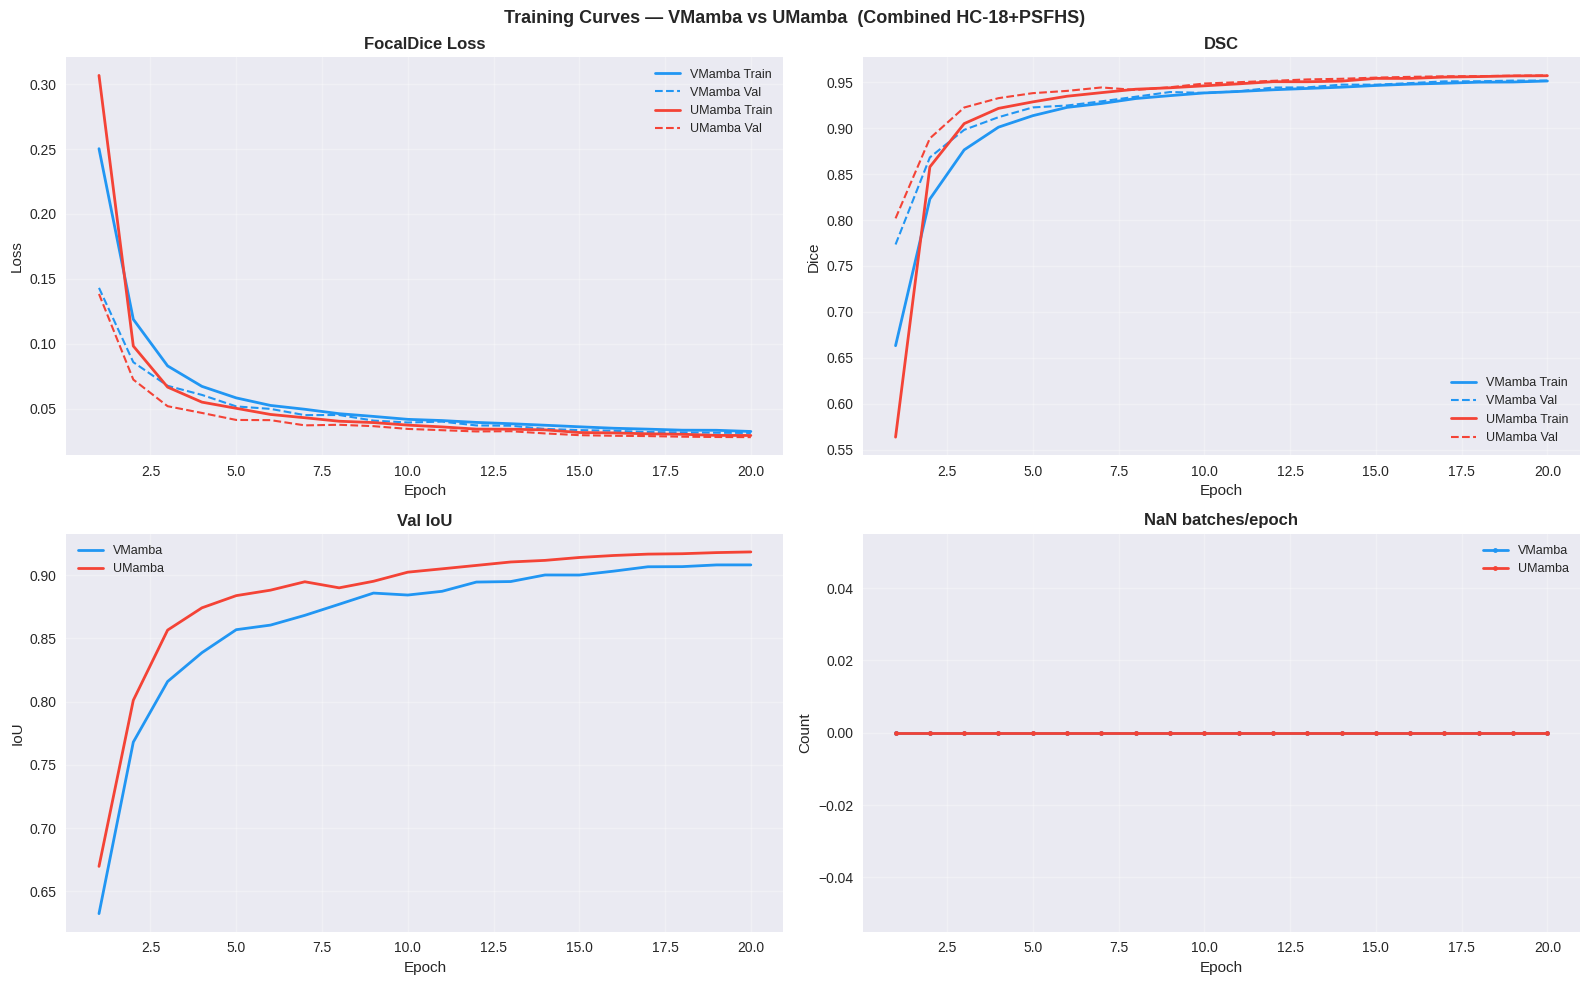

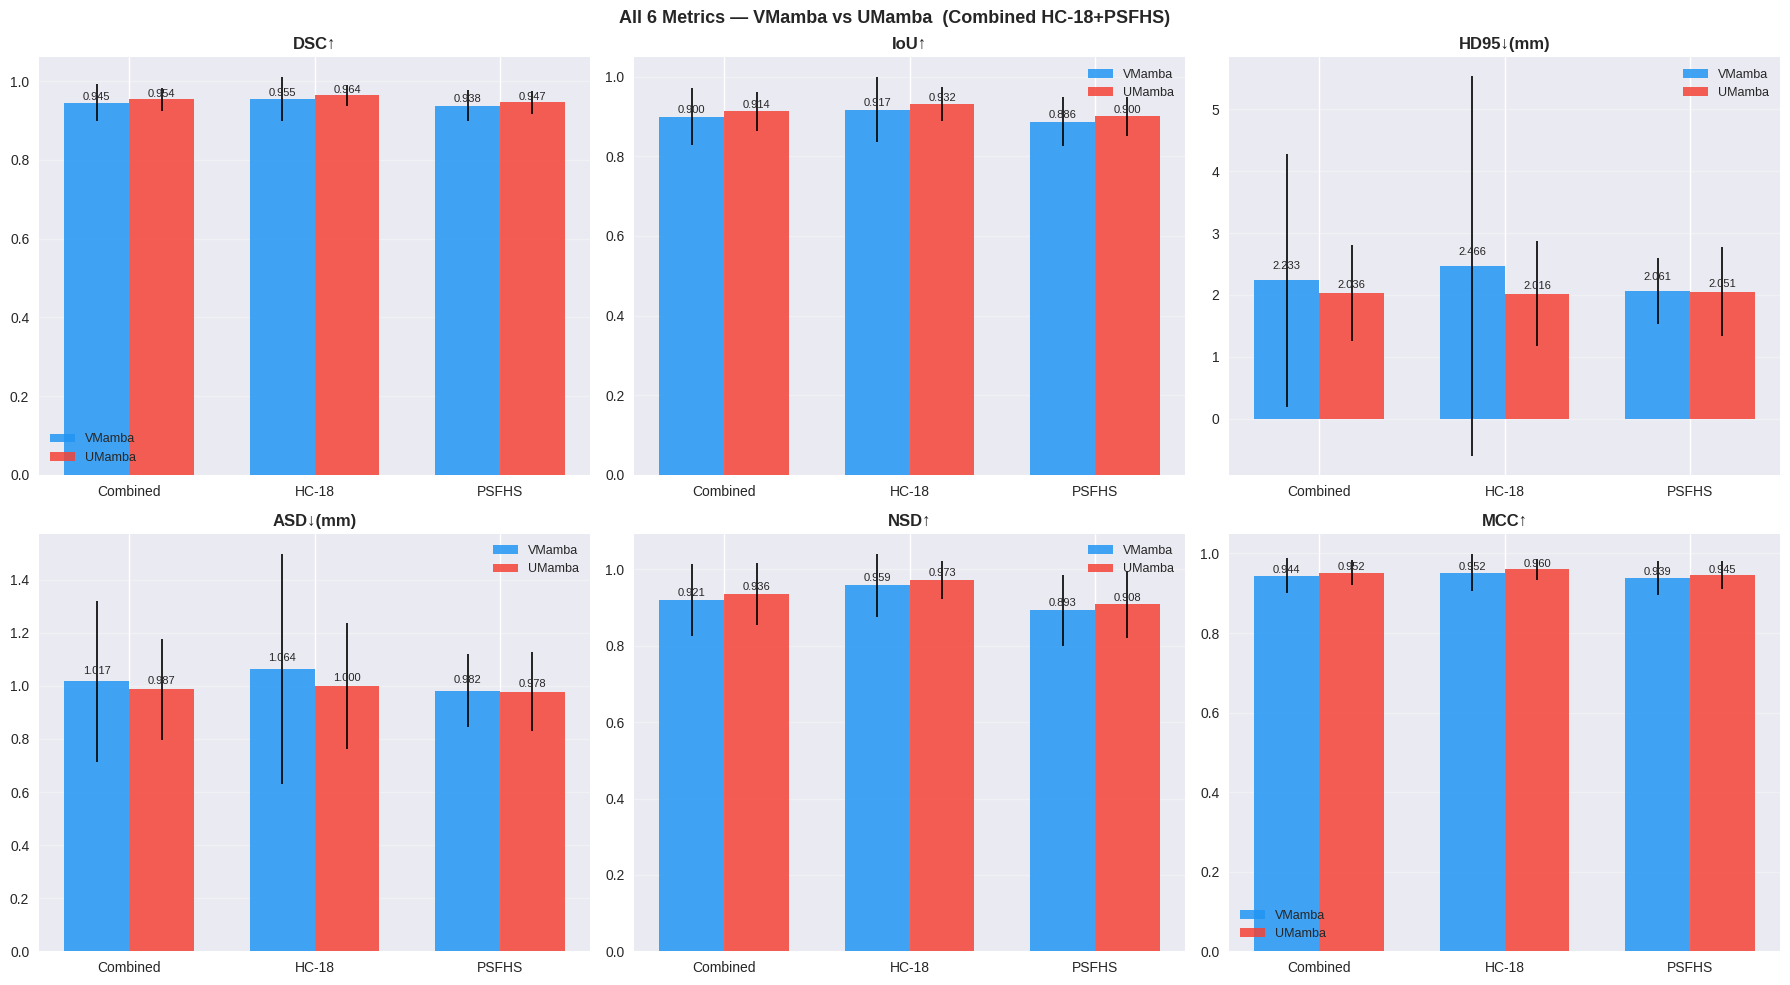

✅  learning_curves.png
✅  all_metrics_bar.png
✅  results_combined.csv
✅  efficiency_table.csv


In [14]:
# ════════════════════════════════════════════════════════
#  CELL 13 – Plots
# ════════════════════════════════════════════════════════

# ── A) Learning curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Curves — VMamba vs UMamba  (Combined HC-18+PSFHS)',
             fontsize=13, fontweight='bold')
COLORS = {'VMamba': '#2196F3', 'UMamba': '#F44336'}

for model_name, info in all_histories.items():
    h   = info['history']
    E   = range(1, len(h['train_dsc']) + 1)
    col = COLORS.get(model_name, 'grey')
    axes[0,0].plot(E, h['train_loss'], col, ls='-',  lw=2,   label=f"{model_name} Train")
    axes[0,0].plot(E, h['val_loss'],   col, ls='--', lw=1.5, label=f"{model_name} Val")
    axes[0,1].plot(E, h['train_dsc'],  col, ls='-',  lw=2,   label=f"{model_name} Train")
    axes[0,1].plot(E, h['val_dsc'],    col, ls='--', lw=1.5, label=f"{model_name} Val")
    axes[1,0].plot(E, h['val_iou'],    col, ls='-',  lw=2,   label=model_name)
    axes[1,1].plot(E, h['nan_batches'],col, ls='-',  lw=2,   label=model_name, marker='.')

for ax, (title, yl) in zip(axes.flat, [('FocalDice Loss','Loss'), ('DSC','Dice'),
                                        ('Val IoU','IoU'), ('NaN batches/epoch','Count')]):
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.set_ylabel(yl); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# ── B) Bar chart — 6 metrics × 3 splits × 2 models ──────────────────────────
MK_PLOT = ['dsc','iou','hd95','asd','nsd','mcc']
ML_PLOT = ['DSC↑','IoU↑','HD95↓(mm)','ASD↓(mm)','NSD↑','MCC↑']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('All 6 Metrics — VMamba vs UMamba  (Combined HC-18+PSFHS)',
             fontsize=13, fontweight='bold')
SPLITS   = [('all','Combined'), ('hc18','HC-18'), ('psfhs','PSFHS')]
PAL      = ['#2196F3','#F44336']
x        = np.arange(len(SPLITS))
width    = 0.35

for ax, (mk, ml) in zip(axes.flat, zip(MK_PLOT, ML_PLOT)):
    for mi, (model_name, info) in enumerate(all_histories.items()):
        means, stds = [], []
        for sk, _ in SPLITS:
            vals = np.array([v for v in final_results[model_name][sk][mk] if not np.isnan(v)])
            means.append(vals.mean() if len(vals) > 0 else 0)
            stds.append( vals.std()  if len(vals) > 0 else 0)
        offset = (mi - len(all_histories)/2 + 0.5) * width
        bars = ax.bar(x + offset, means, width, yerr=stds, capsize=4,
                      color=PAL[mi], alpha=0.85, label=model_name,
                      error_kw=dict(elinewidth=1.2, ecolor='black'))
        for bar, mu in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(stds, default=0)*0.05,
                    f"{mu:.3f}", ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([s[1] for s in SPLITS])
    ax.set_title(ml, fontweight='bold'); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('all_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅  learning_curves.png")
print("✅  all_metrics_bar.png")
print("✅  results_combined.csv")
print("✅  efficiency_table.csv")
